# Global EDA on metadata

## Analyse des metadata sur les différentes espèces

In [6]:
import pandas as pd
import importlib

import functions_eda

In [7]:
taxonomy = pd.read_csv("data/taxonomy.csv")

print("Nombre d'espèces :", len(taxonomy["primary_label"].unique()))
print("Nombre de familles :", len(taxonomy["class_name"].unique()))

Nombre d'espèces : 234
Nombre de familles : 5


In [8]:
importlib.reload(functions_eda)

<module 'functions_eda' from 'd:\\ML\\ML_Project\\functions_eda.py'>

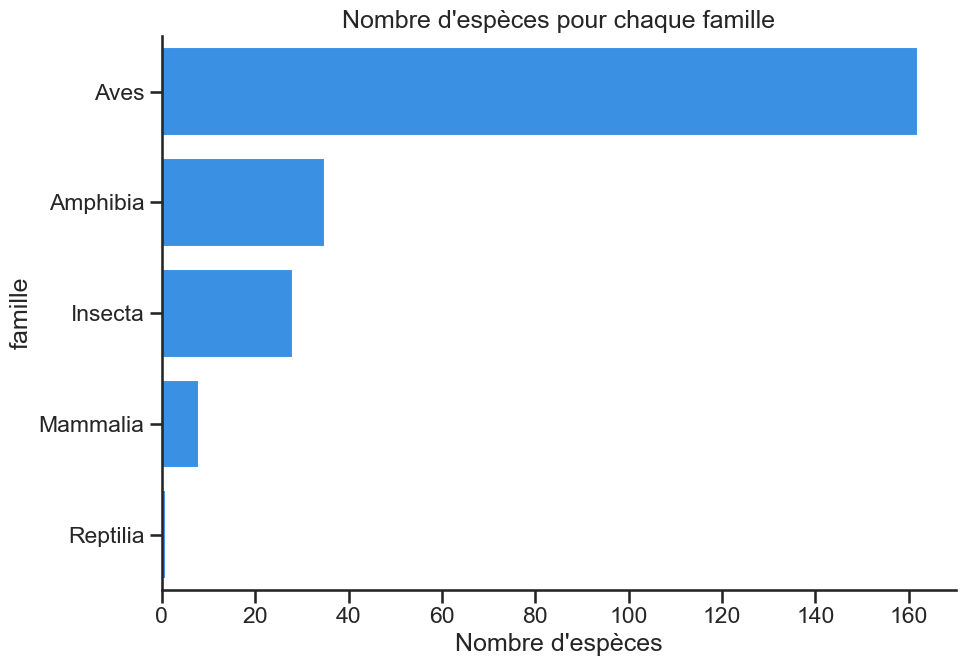

In [9]:
# Nombre d'espèces par famille
functions_eda.group_by_barplot(taxonomy["class_name"], "famille", "d'espèces")

### Comparaison de MFCC pour chaque famille

<StringArray>
['Insecta', 'Reptilia', 'Amphibia', 'Mammalia', 'Aves']
Length: 5, dtype: str


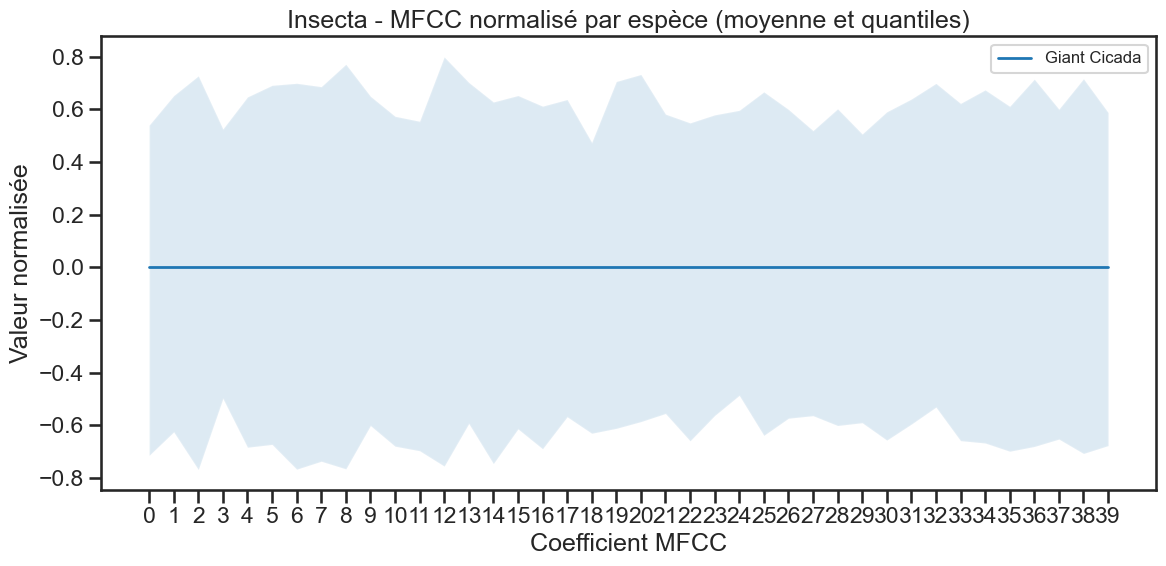

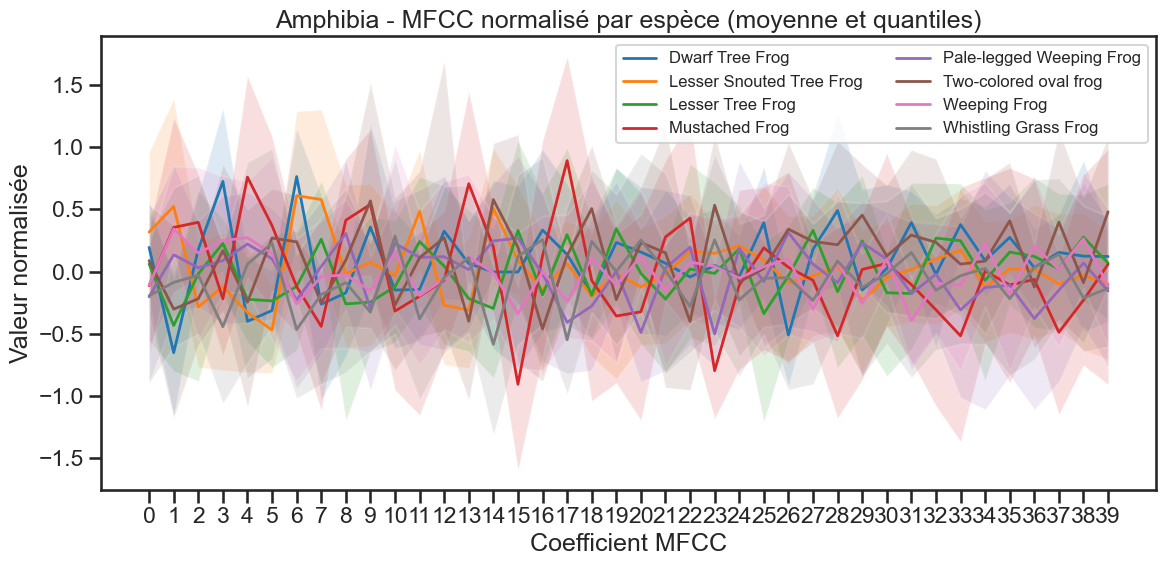

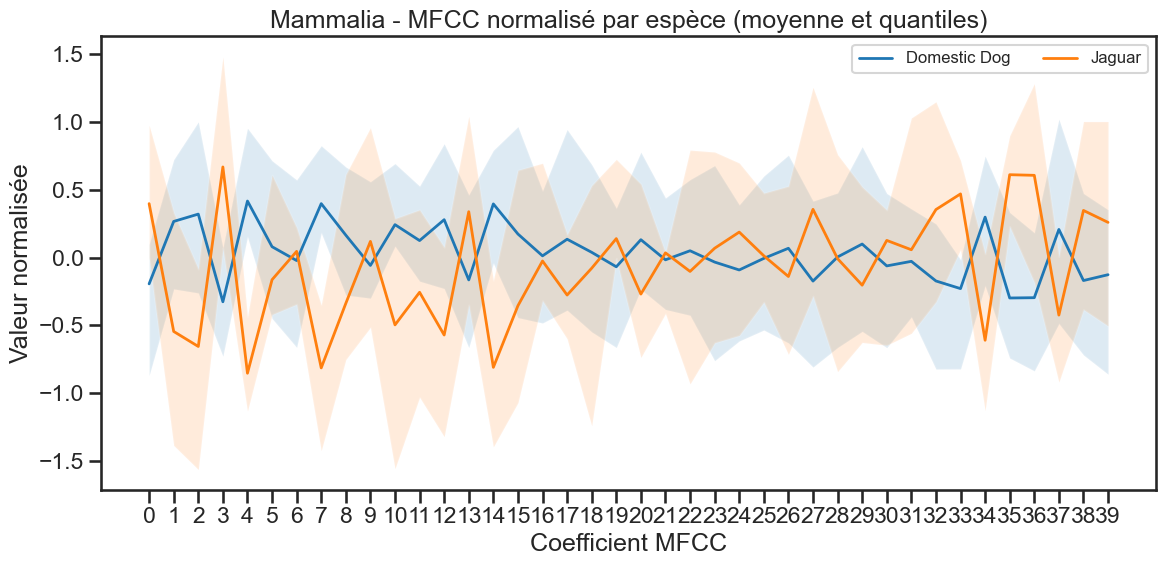

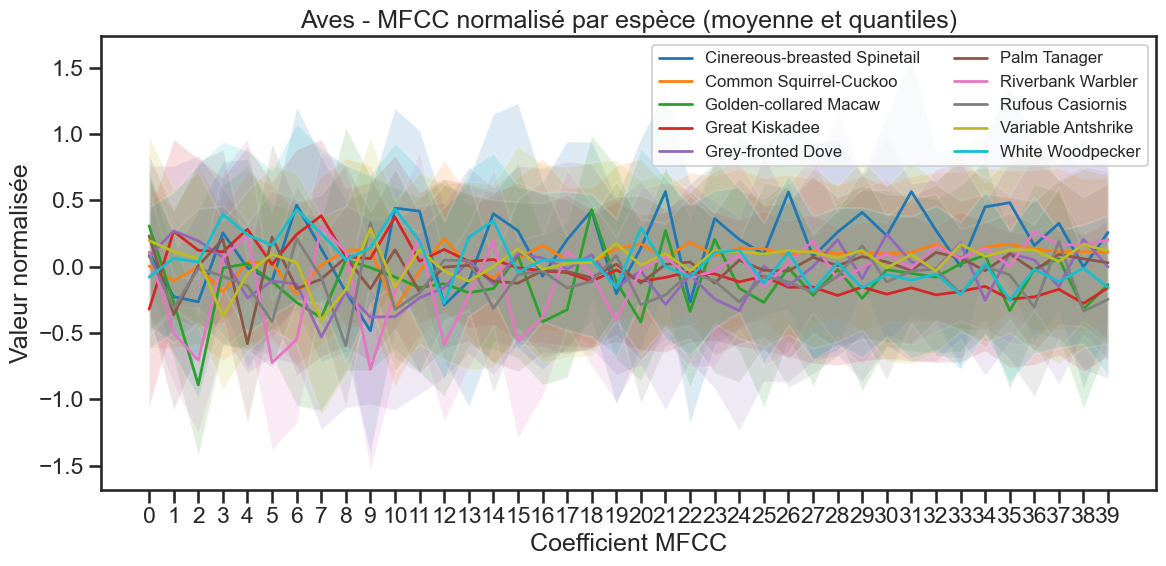

: 

In [ ]:
train_audio = pd.read_csv("eda_csv/train_audio_metadata.csv")

# Ajout d'une colonne de noms communs des espèces pour l'affichage
train_audio_common_name = train_audio.copy()
common_name_map = taxonomy.set_index("primary_label")["common_name"].to_dict()
train_audio_common_name["common_name"] = train_audio_common_name["species_id"].map(common_name_map)
train_audio_common_name = train_audio_common_name.dropna(subset=["common_name"])

for family in taxonomy["class_name"].unique():
    species_id_family = taxonomy.loc[taxonomy["class_name"] == family]["primary_label"].tolist()
    family_species_id = train_audio_common_name.loc[train_audio_common_name["species_id"].isin(species_id_family)]
    functions_eda.compare_mfcc(family_species_id, "common_name", "espèce", family)

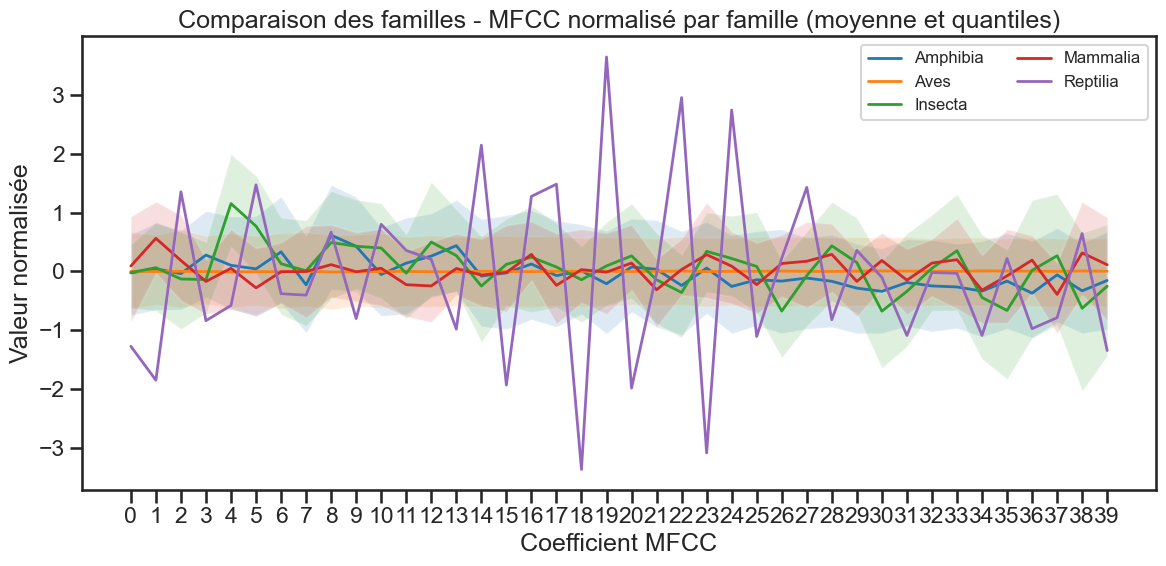

In [11]:
# Ajout d'une colonne famille
train_audio_family = train_audio.copy()
family_map = taxonomy.set_index("primary_label")["class_name"].to_dict()
train_audio_family["class_name"] = train_audio_family["species_id"].map(family_map)
train_audio_family = train_audio_family.dropna(subset=["class_name"])

functions_eda.compare_mfcc(train_audio_family, "class_name", "famille", "Comparaison des familles")